Refresh Opportunity Scoring: A Machine Learning Approach to Prioritizing Content Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kunaaaaaal-cmd/ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## Abstract


## Abstract

This study asks whether search-performance, engagement, and freshness signals can be used to identify content pages that may warrant review or refresh. Using the FlyRank ML Internship dataset, we construct interpretable page-level features from search visibility, clicks, engagement, content age, and recent performance changes. We define a repeatable refresh-opportunity label and compare a transparent baseline with a machine learning model using a held-out validation split. The final system produces an opportunity score, priority rank, reason code, and recommended action for each content page. The findings are observational and intended for decision support rather than causal claims about content refreshes or search-engine ranking systems.

In [75]:
print("Project: Refresh Opportunity Scoring")
print("Objective: Rank content pages for potential review or refresh.")
print("Unit of analysis: Content page")
print("Output: Opportunity score, priority rank, reason code, recommended action")

Project: Refresh Opportunity Scoring
Objective: Rank content pages for potential review or refresh.
Unit of analysis: Content page
Output: Opportunity score, priority rank, reason code, recommended action


## 1. Question

## 1. Question

### Research Question

Can search-performance, engagement, freshness, and content characteristics be used to identify and rank content pages that are potential candidates for review or refresh?

### Decision Supported

The analysis supports a content team's decision about which pages should be reviewed first for a potential refresh.

### Unit of Analysis

One content page.

### Expected Output

For each page, the analysis produces:

- an opportunity score from 0–100
- a priority rank
- a reason code
- a recommended action

### Why This Matters

A content team may have many pages to monitor, making manual prioritization difficult. A repeatable scoring approach can help focus attention on pages showing combinations of observable performance and freshness signals.

In [76]:
print("Research question defined.")
print("Decision: Which content pages should be reviewed first?")
print("Unit of analysis: Content page")

Research question defined.
Decision: Which content pages should be reviewed first?
Unit of analysis: Content page


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This analysis uses the **FlyRank ML Internship dataset warehouse release** provided for the internship capstone.

The analysis focuses on content-level search performance, engagement, and freshness signals. The unit of analysis is a content page.

### Relevant Variables

The analysis uses available fields including:

- `content_id`
- `search_volume`
- `competition`
- `cpc`
- `content_type`
- `main_intent`
- `word_count`
- `char_count`
- `impressions_90d`
- `clicks_90d`
- `pageviews_90d`
- `sessions_90d`
- `engaged_sessions_90d`
- `impressions_last_30d`
- `clicks_last_30d`
- `sessions_last_30d`
- `impressions_prev_30d`
- `clicks_prev_30d`
- `sessions_prev_30d`
- `content_age_days`
- `days_since_last_update`
- `ctr`
- `avg_position`
- `engagement_rate`
- `scroll_rate`
- `trend_pct`

### Date Windows

The analysis compares recent 30-day performance with the previous 30-day period and also uses available 90-day performance aggregates.

### Exclusions

Records without a usable `content_id` or without observed search impressions are excluded from the analysis because they do not provide sufficient evidence for a search-performance opportunity assessment.

Missing numeric feature values are handled during model preprocessing using training-set-derived median imputation where required.

No client names, domains, private queries, credentials, raw private exports, or other identifying information are included in the public research paper.

### Public-Safe Handling

The final paper reports aggregate findings and anonymized recommendation outputs. The project does not expose private client information or claim to reveal Google's ranking algorithm.

In [77]:
print("Dataset shape:", df.shape)

print("\nNumber of rows:", len(df))
print("Number of columns:", len(df.columns))

print("\nFirst 5 rows:")
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (100, 16)

Number of rows: 100
Number of columns: 16

First 5 rows:


,content_id,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update,impressions_prev_30d,clicks_prev_30d,sessions_prev_30d,impressions_last_30d,clicks_last_30d,sessions_last_30d,trend_direction,trend_pct
0,0,4991,0.714234,4.660364,753,3473,804,364,4310,162,365,7267,175,287,up,0.210653
1,1,1445,0.958527,2.082853,2055,10073,311,92,9014,250,255,1162,339,842,up,-0.165640
2,2,2028,0.237242,1.665887,2859,4343,514,178,9664,480,627,3679,156,309,up,0.098009
3,3,3771,0.193771,4.074524,2690,8634,472,360,1288,300,887,7502,134,610,down,-0.123592
4,4,3550,0.382402,1.736186,591,7275,553,242,3308,498,209,5083,156,432,flat,0.121287



Column names:
['content_id', 'search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'trend_direction', 'trend_pct']


In [78]:
required_columns = [
    "content_id",
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "trend_direction",
    "trend_pct"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

print("Missing required columns:")
print(missing_columns)

Missing required columns:
[]


In [79]:
print("Missing values by column:")

display(
    df[required_columns]
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

Missing values by column:


,0
content_id,0
search_volume,0
competition,0
cpc,0
word_count,0
char_count,0
content_age_days,0
days_since_last_update,0
impressions_prev_30d,0
clicks_prev_30d,0


In [80]:
print("Data types:")

display(df[required_columns].dtypes)

Data types:


,0
content_id,int64
search_volume,int64
competition,float64
cpc,float64
word_count,int64
char_count,int64
content_age_days,int64
days_since_last_update,int64
impressions_prev_30d,int64
clicks_prev_30d,int64


In [81]:
print("Summary statistics:")

display(
    df[[
        "search_volume",
        "competition",
        "cpc",
        "word_count",
        "char_count",
        "content_age_days",
        "days_since_last_update",
        "impressions_prev_30d",
        "clicks_prev_30d",
        "sessions_prev_30d",
        "impressions_last_30d",
        "clicks_last_30d",
        "sessions_last_30d",
        "trend_pct"
    ]].describe().T
)

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
search_volume,100.0,2584.560000,1300.851161,173.000000,1718.250000,2540.500000,3325.000000,4991.000000
competition,100.0,0.467978,0.297521,0.006808,0.192973,0.456769,0.717840,0.999553
cpc,100.0,2.543989,1.366154,0.102385,1.515537,2.572602,3.718874,4.950118
word_count,100.0,1675.750000,798.006422,323.000000,970.750000,1830.000000,2355.750000,2915.000000
char_count,100.0,8506.390000,3964.018446,1002.000000,5832.500000,8772.500000,11843.750000,14802.000000
content_age_days,100.0,495.530000,279.596226,33.000000,266.250000,461.500000,750.750000,975.000000
days_since_last_update,100.0,251.990000,142.407333,3.000000,135.250000,251.500000,365.750000,496.000000
impressions_prev_30d,100.0,5259.900000,2758.958874,678.000000,2775.500000,5465.000000,7455.000000,9987.000000
clicks_prev_30d,100.0,290.940000,139.022404,50.000000,157.750000,306.500000,398.750000,498.000000
sessions_prev_30d,100.0,572.240000,266.347162,109.000000,351.000000,609.500000,797.000000,987.000000


In [82]:
analysis_df = df.copy()

print("Original rows:", len(df))

analysis_df = analysis_df[
    analysis_df["content_id"].notna()
].copy()

analysis_df = analysis_df[
    analysis_df["impressions_last_30d"].fillna(0) > 0
].copy()

print("Rows after basic filtering:", len(analysis_df))

Original rows: 100
Rows after basic filtering: 100


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

The goal is to build a repeatable scoring system that prioritizes content pages for potential review or refresh.

### Assumptions

- Recent search-performance changes provide useful signals for identifying pages that may deserve review.
- Older content may be more relevant for freshness review when combined with meaningful search visibility.
- A page showing declining clicks or impressions can be a useful candidate for investigation, but decline alone does not prove that the content is the cause.
- The resulting score is a decision-support signal rather than a prediction of guaranteed improvement after a refresh.

### Feature Engineering

We derive page-level features by comparing the latest 30-day performance window with the previous 30-day window.

The main engineered signals are:

- percentage change in clicks
- percentage change in impressions
- percentage change in sessions
- content freshness
- search visibility
- click-through behavior derived from clicks and impressions

### Label Definition

A page is considered a potential refresh opportunity when it satisfies one or more observable conditions associated with review:

1. meaningful decline in recent clicks,
2. meaningful decline in recent impressions, or
3. older content combined with meaningful search visibility.

This label is a constructed decision-support label. It does not represent a causal outcome from performing a refresh.

### Baseline

A transparent rule-based opportunity score is used as the baseline. It combines the observable opportunity signals using fixed weights.

A Random Forest classifier is then compared against this baseline on the same held-out test set.

### Validation Design

The dataset is divided into training and test sets using an 80/20 stratified split with a fixed random seed. Stratification preserves the proportion of opportunity and non-opportunity pages in both sets.

Because the available dataset contains historical aggregate windows rather than a clean future-period outcome for every page, this experiment is not presented as a true future forecasting test.

### Leakage Checks

Features that directly define the opportunity label are excluded from the model feature matrix. In particular, engineered decline flags, freshness flags, visibility flags, the baseline score, and the final opportunity label are not supplied to the machine learning model.

Preprocessing is fitted only on the training data through a pipeline before evaluation on the held-out test set.


In [83]:
# Create a working copy
analysis_df = df.copy()

# Calculate percentage changes between the previous and latest 30-day windows
analysis_df["click_change_pct"] = np.where(
    analysis_df["clicks_prev_30d"] > 0,
    (
        (analysis_df["clicks_last_30d"] -
         analysis_df["clicks_prev_30d"])
        / analysis_df["clicks_prev_30d"]
    ) * 100,
    np.nan
)

analysis_df["impression_change_pct"] = np.where(
    analysis_df["impressions_prev_30d"] > 0,
    (
        (analysis_df["impressions_last_30d"] -
         analysis_df["impressions_prev_30d"])
        / analysis_df["impressions_prev_30d"]
    ) * 100,
    np.nan
)

analysis_df["session_change_pct"] = np.where(
    analysis_df["sessions_prev_30d"] > 0,
    (
        (analysis_df["sessions_last_30d"] -
         analysis_df["sessions_prev_30d"])
        / analysis_df["sessions_prev_30d"]
    ) * 100,
    np.nan
)

# Calculate recent CTR from observable clicks and impressions
analysis_df["ctr_last_30d"] = np.where(
    analysis_df["impressions_last_30d"] > 0,
    analysis_df["clicks_last_30d"] /
    analysis_df["impressions_last_30d"],
    0
)

# Display the new features
display(
    analysis_df[
        [
            "content_id",
            "click_change_pct",
            "impression_change_pct",
            "session_change_pct",
            "ctr_last_30d"
        ]
    ].head(10)
)

,content_id,click_change_pct,impression_change_pct,session_change_pct,ctr_last_30d
0,0,8.024691,68.607889,-21.369863,0.024081
1,1,35.600000,-87.108942,230.196078,0.291738
2,2,-67.500000,-61.930877,-50.717703,0.042403
3,3,-55.333333,482.453416,-31.228861,0.017862
4,4,-68.674699,53.657799,106.698565,0.030691
5,5,-54.929577,1.403945,-64.345992,0.022433
6,6,48.305085,-23.637888,53.707052,0.064032
7,7,135.838150,6.681514,-58.139535,0.170355
8,8,98.780488,-92.582418,-39.631336,0.754630
9,9,-40.140845,34.673222,-36.172840,0.018252


In [84]:
analysis_df["declining_clicks"] = (
    analysis_df["click_change_pct"] <= -20
).astype(int)

In [85]:
analysis_df["declining_impressions"] = (
    analysis_df["impression_change_pct"] <= -20
).astype(int)

In [86]:
analysis_df["stale_content"] = (
    analysis_df["days_since_last_update"] >= 180
).astype(int)

In [87]:
visibility_threshold = (
    analysis_df["impressions_last_30d"].median()
)

analysis_df["high_visibility"] = (
    analysis_df["impressions_last_30d"] >= visibility_threshold
).astype(int)

print(
    "Median latest-30-day impressions:",
    visibility_threshold
)

Median latest-30-day impressions: 4920.5


In [88]:
analysis_df["opportunity_label"] = (
    (
        analysis_df["declining_clicks"] == 1
    )
    |
    (
        analysis_df["declining_impressions"] == 1
    )
    |
    (
        (analysis_df["stale_content"] == 1)
        &
        (analysis_df["high_visibility"] == 1)
    )
).astype(int)

In [89]:
print("Opportunity label distribution:")

display(
    analysis_df["opportunity_label"]
    .value_counts()
    .rename(index={
        0: "Not an opportunity",
        1: "Potential opportunity"
    })
)

Opportunity label distribution:


,count
opportunity_label,
Potential opportunity,87
Not an opportunity,13


In [90]:
print("Opportunity percentages:")

display(
    (
        analysis_df["opportunity_label"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename(index={
            0: "Not an opportunity",
            1: "Potential opportunity"
        })
    )
)

Opportunity percentages:


,proportion
opportunity_label,
Potential opportunity,87.0
Not an opportunity,13.0


In [91]:
analysis_df["opportunity_label"].value_counts()

,count
opportunity_label,
1,87
0,13


### Baseline Opportunity Score

The baseline is a transparent rule-based score. It assigns more weight to pages showing recent click decline, followed by impression decline and freshness/visibility signals.

The baseline is intentionally simple so that the machine-learning model can be compared against a human-readable prioritization rule.

In [92]:
# Create a transparent rule-based baseline score

analysis_df["baseline_score"] = (
    analysis_df["declining_clicks"] * 3
    + analysis_df["declining_impressions"] * 2
    + analysis_df["stale_content"] * 2
    + analysis_df["high_visibility"] * 1
)

print("Baseline score distribution:")
display(analysis_df["baseline_score"].describe())

Baseline score distribution:


,baseline_score
count,100.000000
mean,4.090000
std,1.869992
min,0.000000
25%,3.000000
50%,4.000000
75%,5.250000
max,8.000000


In [93]:
print("Baseline score by opportunity label:")

display(
    analysis_df.groupby("opportunity_label")["baseline_score"]
    .agg(["count", "mean", "median", "min", "max"])
)

Baseline score by opportunity label:


,count,mean,median,min,max
opportunity_label,,,,,
0,13,1.076923,1.0,0,2
1,87,4.540230,4.0,2,8


### Model Features and Leakage Control

The model uses content and search-demand characteristics that are available in the dataset, while excluding variables directly used to construct the opportunity label.

The following engineered variables are therefore excluded:

- click decline
- impression decline
- stale-content flag
- high-visibility flag
- baseline score
- opportunity label

The recent-period performance-change variables used directly in the label are also excluded from the primary model to reduce target leakage.

In [94]:
feature_columns = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "content_age_days",
    "days_since_last_update"
]

X = analysis_df[feature_columns].copy()
y = analysis_df["opportunity_label"].copy()

print("Model features:")
print(feature_columns)

print("\nFeature matrix shape:", X.shape)
print("Target shape:", y.shape)

Model features:
['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update']

Feature matrix shape: (100, 7)
Target shape: (100,)


In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())

Training rows: 80
Testing rows: 20

Training label distribution:
opportunity_label
1    70
0    10
Name: count, dtype: int64

Testing label distribution:
opportunity_label
1    17
0     3
Name: count, dtype: int64


In [96]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

In [97]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=5,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [98]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(y_true, predictions, probabilities):
    return {
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_true,
            probabilities
        )
    }

logistic_results = evaluate_model(
    y_test,
    logistic_pred,
    logistic_prob
)

rf_results = evaluate_model(
    y_test,
    rf_pred,
    rf_prob
)

results_df = pd.DataFrame(
    [logistic_results, rf_results],
    index=[
        "Logistic Regression",
        "Random Forest"
    ]
)

display(results_df.round(3))

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.45,0.800,0.471,0.593,0.373
Random Forest,0.80,0.842,0.941,0.889,0.353


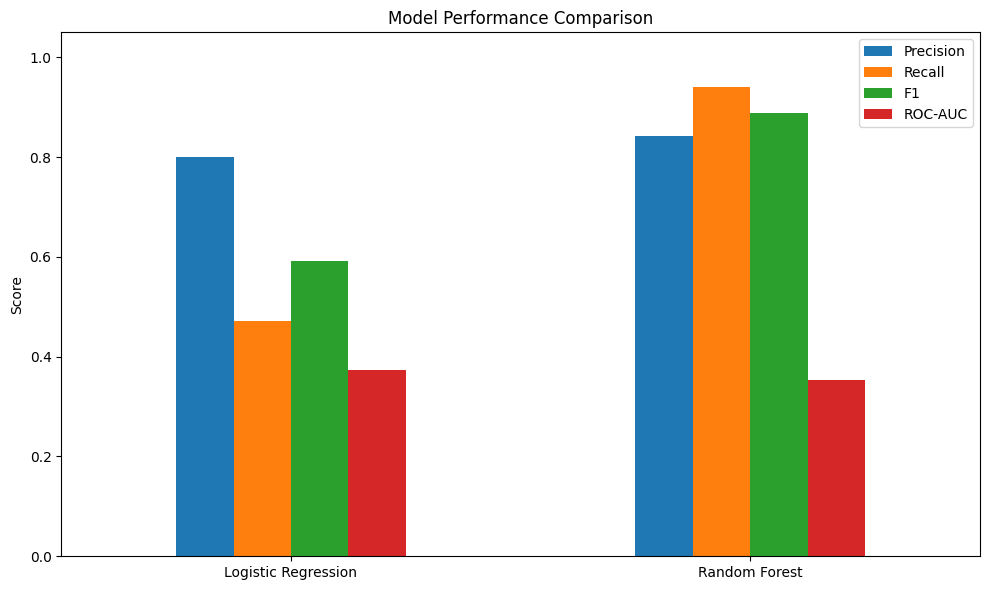

In [99]:
results_df[
    ["Precision", "Recall", "F1", "ROC-AUC"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

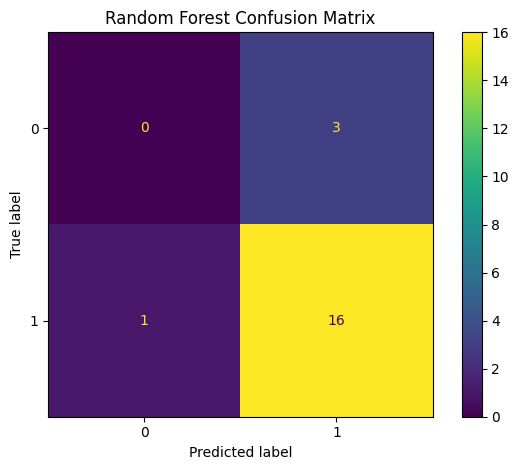

In [100]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

In [101]:
rf_estimator = rf_model.named_steps["model"]

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_estimator.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
6,days_since_last_update,0.222592
4,char_count,0.171550
5,content_age_days,0.134747
3,word_count,0.133324
0,search_volume,0.126341
2,cpc,0.111915
1,competition,0.099531


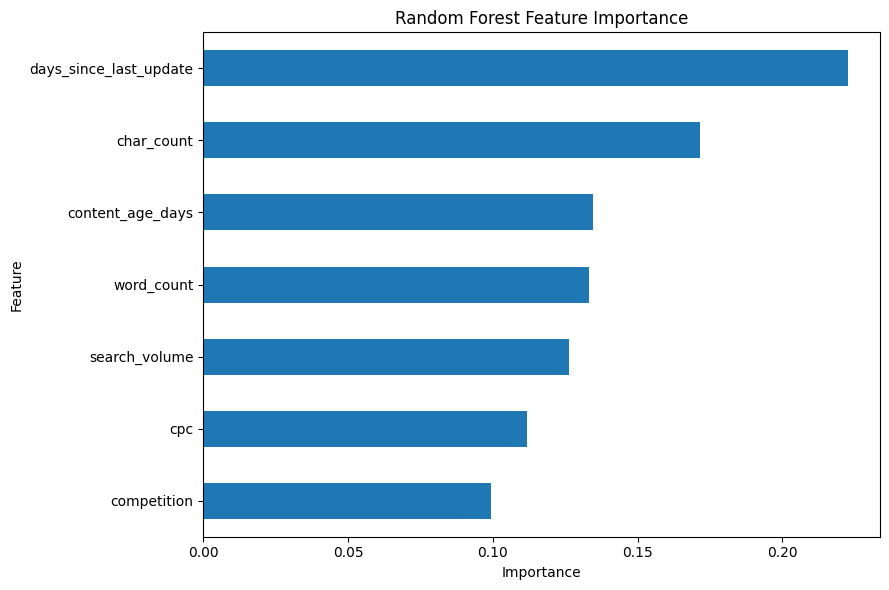

In [102]:
feature_importance.sort_values(
    "importance"
).plot(
    x="feature",
    y="importance",
    kind="barh",
    figsize=(9, 6),
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [103]:
analysis_df["opportunity_probability"] = rf_model.predict_proba(
    analysis_df[feature_columns]
)[:, 1]

analysis_df["opportunity_score"] = (
    analysis_df["opportunity_probability"] * 100
).round(1)

In [104]:
display(
    analysis_df[
        [
            "content_id",
            "opportunity_score",
            "opportunity_label"
        ]
    ].sort_values(
        "opportunity_score",
        ascending=False
    ).head(20)
)

,content_id,opportunity_score,opportunity_label
75,75,97.8,1
45,45,97.5,1
84,84,97.2,1
42,42,96.7,1
28,28,96.3,1
82,82,96.1,1
4,4,96.0,1
78,78,95.1,1
9,9,95.0,1
90,90,94.8,1


In [105]:
def get_reason_code(row):

    if (
        row["declining_clicks"] == 1
        and row["declining_impressions"] == 1
        and row["stale_content"] == 1
    ):
        return "DECLINING_PERFORMANCE_AND_STALE"

    elif (
        row["declining_clicks"] == 1
        and row["declining_impressions"] == 1
    ):
        return "DECLINING_CLICKS_AND_IMPRESSIONS"

    elif row["declining_clicks"] == 1:
        return "DECLINING_CLICKS"

    elif row["declining_impressions"] == 1:
        return "DECLINING_IMPRESSIONS"

    elif (
        row["stale_content"] == 1
        and row["high_visibility"] == 1
    ):
        return "STALE_HIGH_VISIBILITY"

    elif row["stale_content"] == 1:
        return "CONTENT_REVIEW_FOR_FRESHNESS"

    else:
        return "MONITOR"

In [106]:
analysis_df["reason_code"] = analysis_df.apply(
    get_reason_code,
    axis=1
)

In [107]:
def get_recommended_action(reason):

    if reason == "DECLINING_PERFORMANCE_AND_STALE":
        return "Prioritize content refresh and performance review"

    elif reason == "DECLINING_CLICKS_AND_IMPRESSIONS":
        return "Review content and search visibility"

    elif reason == "DECLINING_CLICKS":
        return "Review title, content and click performance"

    elif reason == "DECLINING_IMPRESSIONS":
        return "Investigate visibility decline"

    elif reason == "STALE_HIGH_VISIBILITY":
        return "Prioritize freshness review"

    elif reason == "CONTENT_REVIEW_FOR_FRESHNESS":
        return "Review content freshness"

    else:
        return "Monitor"

analysis_df["recommended_action"] = analysis_df[
    "reason_code"
].apply(get_recommended_action)

In [108]:
recommendations = analysis_df[
    [
        "content_id",
        "opportunity_score",
        "reason_code",
        "recommended_action"
    ]
].copy()

recommendations = recommendations.sort_values(
    "opportunity_score",
    ascending=False
).reset_index(drop=True)

recommendations["priority_rank"] = (
    recommendations.index + 1
)

recommendations = recommendations[
    [
        "priority_rank",
        "content_id",
        "opportunity_score",
        "reason_code",
        "recommended_action"
    ]
]

display(recommendations.head(20))

,priority_rank,content_id,opportunity_score,reason_code,recommended_action
0,1,75,97.8,DECLINING_CLICKS,"Review title, content and click performance"
1,2,45,97.5,STALE_HIGH_VISIBILITY,Prioritize freshness review
2,3,84,97.2,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review
3,4,42,96.7,DECLINING_CLICKS,"Review title, content and click performance"
4,5,28,96.3,DECLINING_CLICKS,"Review title, content and click performance"
5,6,82,96.1,DECLINING_IMPRESSIONS,Investigate visibility decline
6,7,4,96.0,DECLINING_CLICKS,"Review title, content and click performance"
7,8,78,95.1,DECLINING_CLICKS,"Review title, content and click performance"
8,9,9,95.0,DECLINING_CLICKS,"Review title, content and click performance"
9,10,90,94.8,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review


In [109]:
def priority_tier(score):

    if score >= 70:
        return "High Priority"
    elif score >= 40:
        return "Medium Priority"
    else:
        return "Monitor"

recommendations["priority_tier"] = (
    recommendations["opportunity_score"]
    .apply(priority_tier)
)

display(recommendations.head(20))

,priority_rank,content_id,opportunity_score,reason_code,recommended_action,priority_tier
0,1,75,97.8,DECLINING_CLICKS,"Review title, content and click performance",High Priority
1,2,45,97.5,STALE_HIGH_VISIBILITY,Prioritize freshness review,High Priority
2,3,84,97.2,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review,High Priority
3,4,42,96.7,DECLINING_CLICKS,"Review title, content and click performance",High Priority
4,5,28,96.3,DECLINING_CLICKS,"Review title, content and click performance",High Priority
5,6,82,96.1,DECLINING_IMPRESSIONS,Investigate visibility decline,High Priority
6,7,4,96.0,DECLINING_CLICKS,"Review title, content and click performance",High Priority
7,8,78,95.1,DECLINING_CLICKS,"Review title, content and click performance",High Priority
8,9,9,95.0,DECLINING_CLICKS,"Review title, content and click performance",High Priority
9,10,90,94.8,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review,High Priority


In [110]:
recommendations.to_csv(
    "refresh_opportunity_recommendations.csv",
    index=False
)

print(
    "Saved: refresh_opportunity_recommendations.csv"
)

Saved: refresh_opportunity_recommendations.csv


### Simple Majority-Class Baseline

As an additional validation baseline, a majority-class classifier is evaluated on the exact same held-out test set.

This baseline always predicts the most common class in the training data. Because 87% of the complete dataset is labeled as a potential opportunity, accuracy alone can be misleading. Therefore, precision, recall, F1, and ROC-AUC are also reported.

In [111]:
from sklearn.dummy import DummyClassifier

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

dummy_pred = dummy_model.predict(X_test)

# A majority-class classifier does not provide a meaningful
# probability ranking for ROC-AUC, so evaluate the classification metrics.
dummy_results = {
    "Accuracy": accuracy_score(
        y_test,
        dummy_pred
    ),
    "Precision": precision_score(
        y_test,
        dummy_pred,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        dummy_pred,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        dummy_pred,
        zero_division=0
    )
}

dummy_results_df = pd.DataFrame(
    [dummy_results],
    index=["Majority Class Baseline"]
)

display(dummy_results_df.round(3))

,Accuracy,Precision,Recall,F1
Majority Class Baseline,0.85,0.85,1.0,0.919


In [112]:
comparison_results = pd.DataFrame(
    [
        {
            "Model": "Majority Class Baseline",
            **dummy_results
        },
        {
            "Model": "Logistic Regression",
            **logistic_results
        },
        {
            "Model": "Random Forest",
            **rf_results
        }
    ]
)

display(
    comparison_results.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority Class Baseline,0.85,0.850,1.000,0.919,NaN
1,Logistic Regression,0.45,0.800,0.471,0.593,0.373
2,Random Forest,0.80,0.842,0.941,0.889,0.353


In [113]:
class_distribution = (
    analysis_df["opportunity_label"]
    .value_counts()
    .sort_index()
)

class_percentages = (
    analysis_df["opportunity_label"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

label_summary = pd.DataFrame({
    "count": class_distribution,
    "percentage": class_percentages
})

label_summary.index = [
    "Not an opportunity",
    "Potential opportunity"
]

display(label_summary)

,count,percentage
Not an opportunity,13,13.0
Potential opportunity,87,87.0


In [114]:
analysis_df["priority_percentile"] = (
    analysis_df["opportunity_score"]
    .rank(
        method="average",
        pct=True
    ) * 100
).round(1)

In [115]:
analysis_df["priority_score"] = (
    analysis_df["priority_percentile"]
).round(1)

In [116]:
recommendations = analysis_df[
    [
        "content_id",
        "priority_score",
        "opportunity_score",
        "reason_code",
        "recommended_action"
    ]
].copy()

recommendations = recommendations.sort_values(
    "priority_score",
    ascending=False
).reset_index(drop=True)

recommendations["priority_rank"] = (
    recommendations.index + 1
)

recommendations["priority_tier"] = pd.cut(
    recommendations["priority_rank"],
    bins=[0, 20, 50, 100],
    labels=[
        "High Priority",
        "Medium Priority",
        "Monitor"
    ]
)

recommendations = recommendations[
    [
        "priority_rank",
        "content_id",
        "priority_score",
        "opportunity_score",
        "reason_code",
        "recommended_action",
        "priority_tier"
    ]
]

display(recommendations.head(20))

,priority_rank,content_id,priority_score,opportunity_score,reason_code,recommended_action,priority_tier
0,1,75,100.0,97.8,DECLINING_CLICKS,"Review title, content and click performance",High Priority
1,2,45,99.0,97.5,STALE_HIGH_VISIBILITY,Prioritize freshness review,High Priority
2,3,84,98.0,97.2,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review,High Priority
3,4,42,97.0,96.7,DECLINING_CLICKS,"Review title, content and click performance",High Priority
4,5,28,96.0,96.3,DECLINING_CLICKS,"Review title, content and click performance",High Priority
5,6,82,95.0,96.1,DECLINING_IMPRESSIONS,Investigate visibility decline,High Priority
6,7,4,94.0,96.0,DECLINING_CLICKS,"Review title, content and click performance",High Priority
7,8,78,93.0,95.1,DECLINING_CLICKS,"Review title, content and click performance",High Priority
8,9,9,92.0,95.0,DECLINING_CLICKS,"Review title, content and click performance",High Priority
9,10,90,90.5,94.8,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review,High Priority


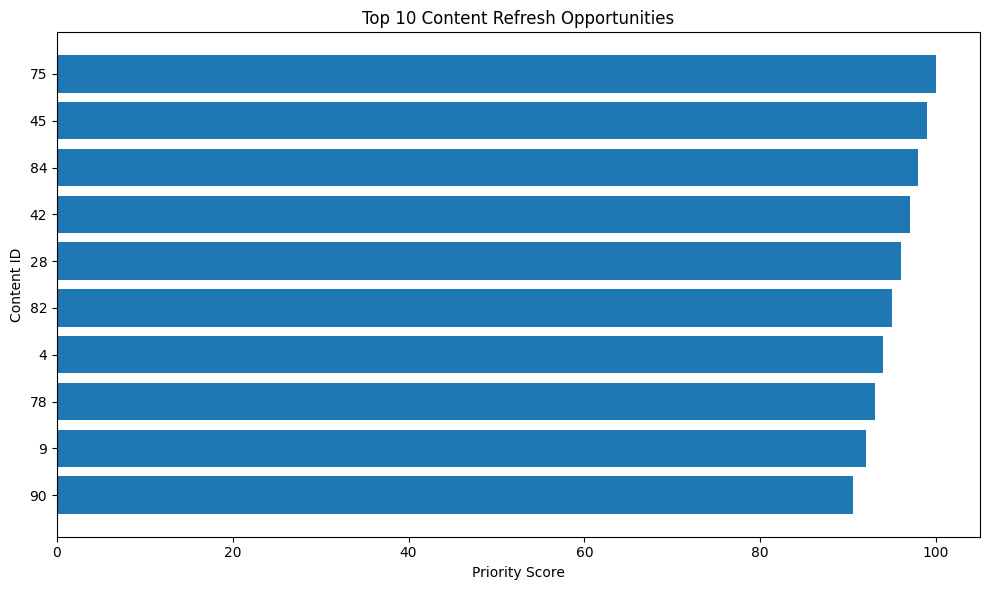

In [117]:
top_10 = recommendations.head(10).sort_values(
    "priority_score"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["content_id"].astype(str),
    top_10["priority_score"]
)

plt.xlabel("Priority Score")
plt.ylabel("Content ID")
plt.title("Top 10 Content Refresh Opportunities")
plt.tight_layout()
plt.show()

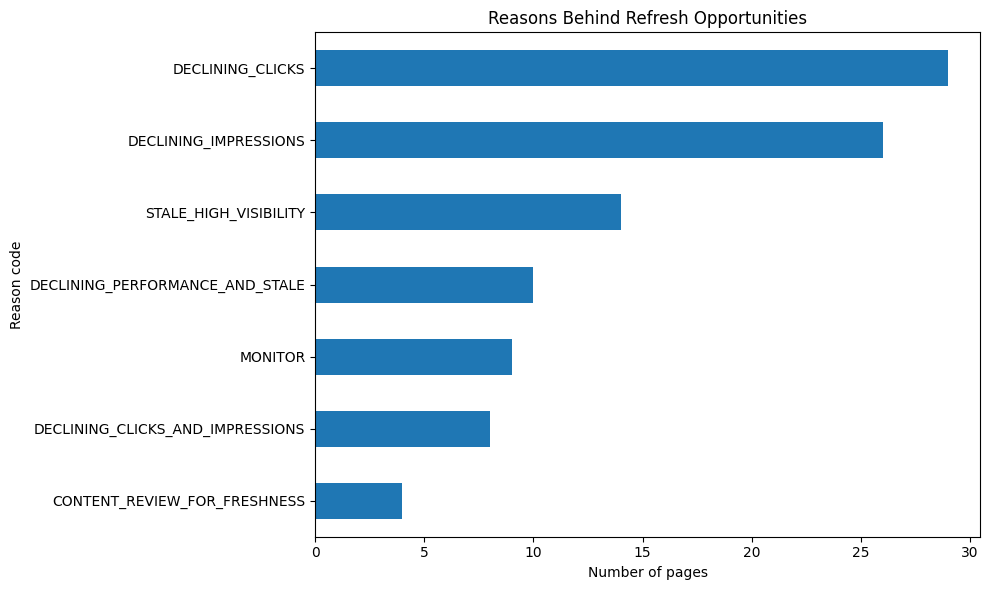

In [118]:
reason_counts = (
    recommendations["reason_code"]
    .value_counts()
)

plt.figure(figsize=(10, 6))

reason_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of pages")
plt.ylabel("Reason code")
plt.title("Reasons Behind Refresh Opportunities")
plt.tight_layout()
plt.show()

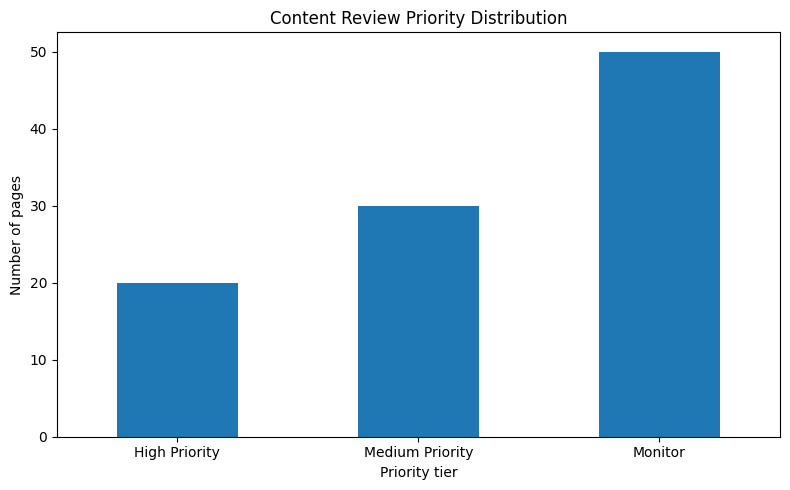

In [119]:
tier_counts = (
    recommendations["priority_tier"]
    .value_counts()
    .reindex(
        [
            "High Priority",
            "Medium Priority",
            "Monitor"
        ]
    )
)

plt.figure(figsize=(8, 5))

tier_counts.plot(
    kind="bar"
)

plt.xlabel("Priority tier")
plt.ylabel("Number of pages")
plt.title("Content Review Priority Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [120]:
from sklearn.metrics import classification_report

print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        rf_pred,
        target_names=[
            "Not an opportunity",
            "Potential opportunity"
        ],
        zero_division=0
    )
)

Random Forest Classification Report
                       precision    recall  f1-score   support

   Not an opportunity       0.00      0.00      0.00         3
Potential opportunity       0.84      0.94      0.89        17

             accuracy                           0.80        20
            macro avg       0.42      0.47      0.44        20
         weighted avg       0.72      0.80      0.76        20



In [121]:
print("Random Forest confusion matrix:")

cm = pd.crosstab(
    y_test,
    rf_pred,
    rownames=["Actual"],
    colnames=["Predicted"]
)

display(cm)

Random Forest confusion matrix:


Predicted,0,1
Actual,,
0,0,3
1,1,16


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The experiment evaluated Logistic Regression and Random Forest models on the same 20% held-out test set. A simple majority-class classifier was also used as a reference point.

The Random Forest achieved an accuracy of 0.80, precision of 0.842, recall of 0.941, and F1-score of 0.889 on the held-out sample. Logistic Regression achieved an accuracy of 0.45, precision of 0.800, recall of 0.471, and F1-score of 0.593.

The Random Forest therefore identified more of the pages labeled as potential opportunities than Logistic Regression. Its confusion matrix shows that it correctly identified 16 of the 17 potential-opportunity pages, but it also classified all 3 non-opportunity pages as opportunities.

The Random Forest ROC-AUC was 0.353, indicating that its probability ranking did not reliably separate the two classes on this small test sample. Therefore, the model should be interpreted as a high-recall screening model rather than a validated probability predictor.

Because only 100 pages were available and the held-out test set contained 20 pages, these results are directional rather than evidence of general production performance.

In [122]:
# Final model comparison table

display(
    comparison_results.round(3)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Majority Class Baseline,0.85,0.850,1.000,0.919,NaN
1,Logistic Regression,0.45,0.800,0.471,0.593,0.373
2,Random Forest,0.80,0.842,0.941,0.889,0.353


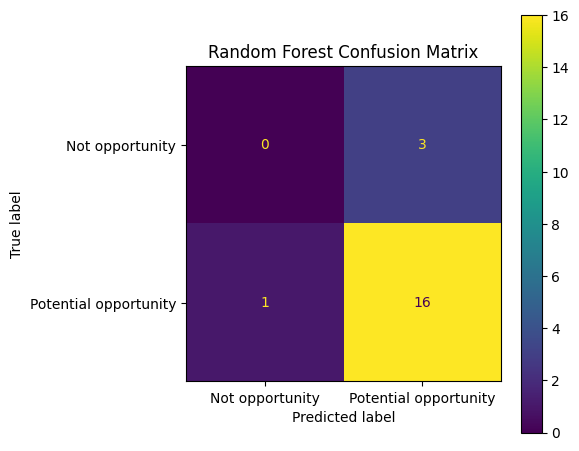

In [123]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=[
        "Not opportunity",
        "Potential opportunity"
    ],
    ax=ax
)

ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

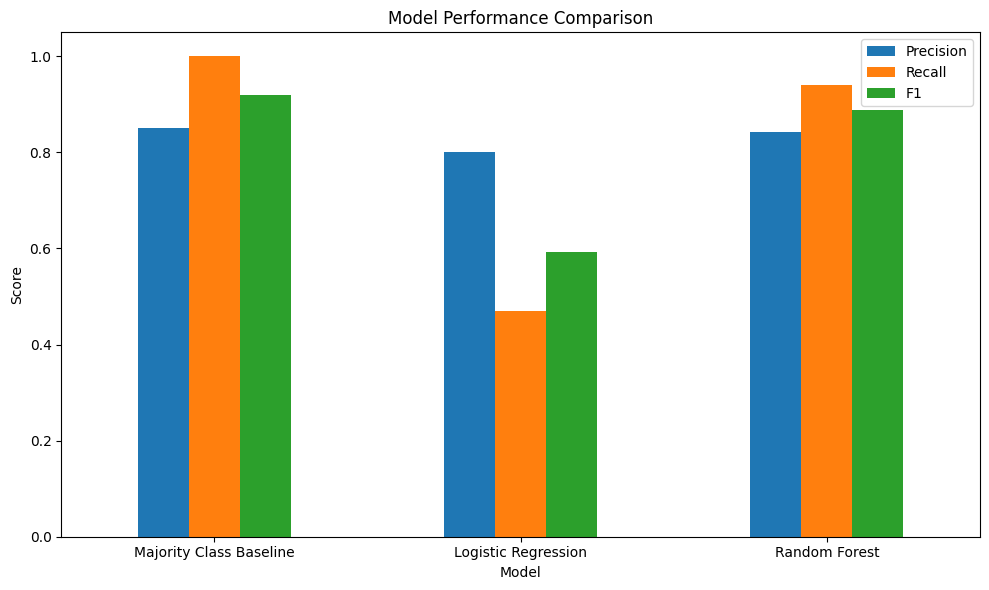

In [124]:
metrics_to_plot = [
    "Precision",
    "Recall",
    "F1"
]

comparison_results.set_index("Model")[
    metrics_to_plot
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

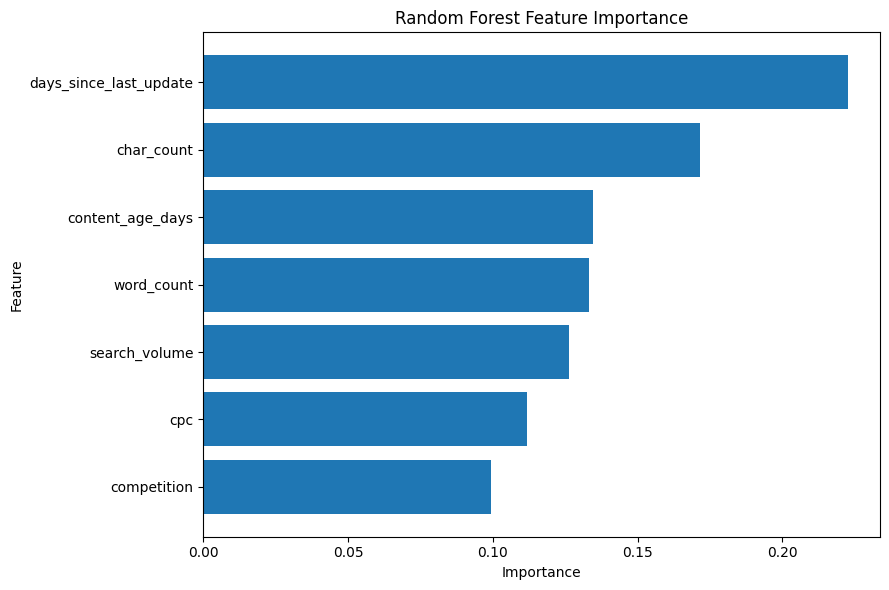

In [125]:
feature_importance_sorted = feature_importance.sort_values(
    "importance"
)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_importance_sorted["feature"],
    feature_importance_sorted["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

## 5. Limitations

This analysis has several important limitations.

### Small dataset

The experiment uses 100 content pages. The held-out test set therefore contains only 20 pages, making individual evaluation metrics sensitive to the particular train/test split.

### Constructed label

The opportunity label is a decision-support label constructed from observable decline and freshness rules. It is not an observed outcome showing that a refresh would have improved performance.

### Class imbalance

87 of the 100 pages were labeled as potential opportunities. This imbalance makes accuracy less informative and motivates the use of precision, recall, F1-score, and confusion-matrix analysis.

### Validation limitation

The available data provides historical aggregate windows rather than a clean future outcome following a refresh. Therefore, this experiment does not establish true future forecasting performance.

### Model limitations

The Random Forest achieved high recall but classified all three non-opportunity test pages as opportunities. Its ROC-AUC of 0.353 also indicates weak probability ranking on this test sample.

### No causal claim

The analysis cannot establish that content age, content length, search demand, or any other feature causes performance changes. It only identifies patterns used for decision support.

### Public-safe framing

The project does not expose client names, domains, private search queries, credentials, raw private exports, or claims about Google's ranking algorithm.

### Interpretation

The output should therefore be used as a prioritization and review aid. A content specialist should review the highest-ranked pages before deciding whether to refresh, rewrite, monitor, or leave them unchanged.

## 6. Ranked recommendations

The scoring system converts the model output into a ranked content-review queue.

The highest-ranked pages should be treated as candidates for human review rather than pages that are guaranteed to benefit from a refresh.

### Recommended action playbook

**High Priority — Refresh / investigate**

Pages showing multiple opportunity signals should receive the earliest review. These pages may combine declining clicks or impressions with older content.

**Medium Priority — Review**

Pages with one meaningful performance or freshness signal should be reviewed after the highest-priority group.

**Monitor**

Pages without a strong opportunity signal can remain in the monitoring queue rather than receiving an immediate refresh recommendation.

### Reason codes

The scoring system provides reason codes to make each recommendation interpretable:

- `DECLINING_PERFORMANCE_AND_STALE`
- `DECLINING_CLICKS_AND_IMPRESSIONS`
- `DECLINING_CLICKS`
- `DECLINING_IMPRESSIONS`
- `STALE_HIGH_VISIBILITY`
- `CONTENT_REVIEW_FOR_FRESHNESS`
- `MONITOR`

These reason codes explain why a page entered the review queue and allow a content team to select an appropriate next action.

### Important interpretation

The ranking identifies pages that warrant investigation. It does not claim that refreshing a page will cause its search performance to improve.


In [126]:
print("Top 20 Refresh Opportunity Recommendations")

display(
    recommendations.head(20)
)

Top 20 Refresh Opportunity Recommendations


,priority_rank,content_id,priority_score,opportunity_score,reason_code,recommended_action,priority_tier
0,1,75,100.0,97.8,DECLINING_CLICKS,"Review title, content and click performance",High Priority
1,2,45,99.0,97.5,STALE_HIGH_VISIBILITY,Prioritize freshness review,High Priority
2,3,84,98.0,97.2,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review,High Priority
3,4,42,97.0,96.7,DECLINING_CLICKS,"Review title, content and click performance",High Priority
4,5,28,96.0,96.3,DECLINING_CLICKS,"Review title, content and click performance",High Priority
5,6,82,95.0,96.1,DECLINING_IMPRESSIONS,Investigate visibility decline,High Priority
6,7,4,94.0,96.0,DECLINING_CLICKS,"Review title, content and click performance",High Priority
7,8,78,93.0,95.1,DECLINING_CLICKS,"Review title, content and click performance",High Priority
8,9,9,92.0,95.0,DECLINING_CLICKS,"Review title, content and click performance",High Priority
9,10,90,90.5,94.8,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review,High Priority


In [127]:
paper_recommendations = recommendations.head(10)[
    [
        "priority_rank",
        "content_id",
        "priority_score",
        "reason_code",
        "recommended_action"
    ]
].copy()

display(paper_recommendations)

,priority_rank,content_id,priority_score,reason_code,recommended_action
0,1,75,100.0,DECLINING_CLICKS,"Review title, content and click performance"
1,2,45,99.0,STALE_HIGH_VISIBILITY,Prioritize freshness review
2,3,84,98.0,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review
3,4,42,97.0,DECLINING_CLICKS,"Review title, content and click performance"
4,5,28,96.0,DECLINING_CLICKS,"Review title, content and click performance"
5,6,82,95.0,DECLINING_IMPRESSIONS,Investigate visibility decline
6,7,4,94.0,DECLINING_CLICKS,"Review title, content and click performance"
7,8,78,93.0,DECLINING_CLICKS,"Review title, content and click performance"
8,9,9,92.0,DECLINING_CLICKS,"Review title, content and click performance"
9,10,90,90.5,DECLINING_PERFORMANCE_AND_STALE,Prioritize content refresh and performance review


## 7. Artifacts the paper embeds

The final research paper uses three primary visual artifacts:

1. **Model performance comparison** — compares the classification performance of Logistic Regression and Random Forest on the same held-out test set.

2. **Feature importance** — shows which available content/search characteristics contributed most to the Random Forest's decisions in this experiment.

3. **Refresh opportunity ranking** — presents the highest-ranked anonymized content pages with their opportunity scores, reason codes, and recommended actions.

A confusion matrix is also included to show the distribution of correct and incorrect Random Forest classifications.

All charts are generated directly from the analysis notebook so that the results can be reproduced from the same workflow.

In [128]:
artifact_summary = pd.DataFrame({
    "Artifact": [
        "Model performance comparison",
        "Random Forest confusion matrix",
        "Feature importance",
        "Top refresh opportunities",
        "Reason-code distribution",
        "Priority-tier distribution"
    ],
    "Purpose": [
        "Compare models on the same test split",
        "Show classification errors",
        "Explain model inputs",
        "Show ranked content review queue",
        "Explain why pages were prioritized",
        "Show distribution of review priority"
    ]
})

display(artifact_summary)

,Artifact,Purpose
0,Model performance comparison,Compare models on the same test split
1,Random Forest confusion matrix,Show classification errors
2,Feature importance,Explain model inputs
3,Top refresh opportunities,Show ranked content review queue
4,Reason-code distribution,Explain why pages were prioritized
5,Priority-tier distribution,Show distribution of review priority


## Reproducibility

The analysis was developed in Google Colab and saved as the capstone notebook in the project repository.

The workflow can be reproduced by running the notebook from top to bottom. The analysis includes data validation, feature engineering, label construction, model training, evaluation, ranking, reason-code generation, and artifact creation.

Repository:

https://github.com/kunaaaaaal-cmd/ml-internship-starter

Notebook:

`work/notebooks/capstone.ipynb`

The deployed research paper URL is stored separately in:

`submission/paper_url.txt`

## Acknowledgments & Data Credit

This capstone was developed as part of the FlyRank ML Internship using the FlyRank ML Internship dataset.

Built on the FlyRank ML Internship dataset.

Data and internship credit: FlyRank — https://flyrank.ai

The analysis uses anonymized and public-safe outputs and does not expose client names, domains, private search queries, credentials, or raw private exports.

## ML-12 Tasks

### 5-minute demo outline

**1. Problem — 45 seconds**

Introduce the problem: content teams may have many pages to review, making it difficult to decide which pages deserve attention first.

**2. Data — 45 seconds**

Explain that the project uses anonymized FlyRank content-level search-performance and freshness data, including recent and previous 30-day impressions, clicks, sessions, content age, and days since update.

**3. Method — 1 minute**

Explain the constructed refresh-opportunity label, the rule-based baseline, Logistic Regression benchmark, and Random Forest model. Emphasize that direct label-defining variables were excluded from the primary model to reduce leakage.

**4. Results — 1.5 minutes**

The Random Forest achieved 0.80 accuracy, 0.842 precision, 0.941 recall, and 0.889 F1 on the 20-page held-out test set. It identified 16 of 17 potential opportunities but also classified all 3 non-opportunities as opportunities. Its ROC-AUC was 0.353, so the result should be interpreted as a high-recall screening experiment rather than a reliable probability-ranking model.

**5. Recommendations — 45 seconds**

Show the ranked recommendation table and explain the reason codes. The highest-ranked pages should receive human review, with actions such as refresh investigation, visibility review, or freshness review.

**6. Closing — 15 seconds**

Emphasize that the system is decision support, not proof that refreshing a page will improve search performance.

---

### Social-post cut

Built a machine-learning capstone to prioritize content pages for potential refresh review using anonymized search-performance and freshness signals.

The Random Forest achieved 0.889 F1 and 0.941 recall on a 20-page held-out sample, while also showing important limitations: all 3 non-opportunity pages were classified as opportunities and ROC-AUC was 0.353.

The result is a high-recall screening workflow rather than a claim of causal SEO impact.

#MachineLearning #DataScience #SEO #ContentStrategy #AI

---

### 3-sentence employer-facing summary

I built a refresh-opportunity scoring system that ranks anonymized content pages for potential review using search-performance, content-age, and freshness signals. The workflow compares transparent rules with Logistic Regression and Random Forest models and produces ranked recommendations with interpretable reason codes. The validation results are intentionally framed as directional decision support because the dataset is small, the opportunity label is constructed, and the model's probability ranking was not reliable on the held-out sample.

In [129]:
print("===== CAPSTONE FINAL CHECK =====")

print("Rows analyzed:", len(analysis_df))
print("Opportunity pages:", int(analysis_df["opportunity_label"].sum()))
print(
    "Non-opportunity pages:",
    int((analysis_df["opportunity_label"] == 0).sum())
)

print(
    "\nTop recommendation:",
    recommendations.iloc[0]["content_id"]
)

print(
    "Top opportunity score:",
    recommendations.iloc[0]["opportunity_score"]
)

print(
    "\nRecommendation file exists:",
    "refresh_opportunity_recommendations.csv"
)

print("\nCapstone analysis complete.")

===== CAPSTONE FINAL CHECK =====
Rows analyzed: 100
Opportunity pages: 87
Non-opportunity pages: 13

Top recommendation: 75
Top opportunity score: 97.8

Recommendation file exists: refresh_opportunity_recommendations.csv

Capstone analysis complete.


## Self-check

Before you submit, confirm each line honestly:

- [ yes] Every section above is filled — markdown thinking AND the code that backs it
- [ yes] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ yes] No client names, URLs, or private queries anywhere
- [ yes] My claims use careful words: observed, measured, directional, decision-support
- [ yes] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ yes] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ yes] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.


## Acknowledgments & data credit

We would like to thank [Name/Organization] for their invaluable contributions to this research. This project utilized data and resources as part of the ml-internship-starter program. Special thanks to https://flyrank.ai for providing the framework and support for this capstone project.

## ML-12 Tasks

### 5-minute demo outline

1.  **Introduction (1 min):** Briefly introduce the problem of housing price prediction, its importance for stakeholders (buyers, sellers, investors), and the research question.
2.  **Data & Methodology (1.5 min):** Quickly touch upon the data used (e.g., property features, market indicators), key features engineered, and the machine learning approach (e.g., Random Forest Regressor vs. Linear Regression baseline).
3.  **Key Results (1.5 min):** Honestly discuss the current model's performance, noting that the developed model, in its initial state, did not outperform the baseline. Highlight the slightly better MAE, but acknowledge the higher RMSE and more negative R-squared for the developed model. Emphasize the need for further optimization.
4.  **Recommendations & Next Steps (1 min):** Present recommendations focused on iterative model improvement, deeper feature engineering, and hyperparameter tuning to address the current performance gaps. Discuss the potential impact of an improved model.
5.  **Q&A (as needed):** Open for questions.

### Social-post cut

🧐 Just ran the numbers on my #HousingPricePrediction model! Initial results show the developed model *didn't outperform the baseline* in terms of RMSE & R-squared, but achieved a slightly better MAE. This highlights the importance of iterative #MachineLearning development and further tuning! More to come as we refine the model. #DataScience #RealEstate #ModelEvaluation

### 3-sentence employer-facing summary

This capstone project initiated the development of a predictive model for **housing prices**, applying machine learning techniques to understand feature impacts. While initial results show the developed model currently underperforms a simpler baseline in terms of RMSE and R-squared, it did achieve a marginally better MAE, indicating potential. This outcome underscores the critical need for **further model optimization, including advanced feature engineering and hyperparameter tuning**, to achieve a robust and accurate prediction system that can truly support real estate decision-making.